In [2]:
# --------------------------
# 🔹 IMPORTS
# --------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from pathlib import Path



In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive


 20JE0283_Chanchal_Rawate_lab_7.docx
 20JE0283.gdoc
'20JE0283_LAB-5 (PERT).docx'
'20JE0283_Lab Experiment 5 - Implementation of Program Evaluation and Review Technique (PERT).gdoc'
'20JE0283- Lab Experiment 5 - Implementation of Program Evaluation and Review Technique (PERT).gdoc'
'4.5 SQL Scripts for Lecture.rar'
'Admission_form (1).jpg'
 Admission_form.jpg
'Application for Employment_Internship (1).gdoc'
'Application for Employment_Internship (1).pdf'
'Ap Sub array variant.gdoc'
'ayushi mam_resume_.pdf .gdoc'
'ayushi mam_resume_.pdf .pdf'
 bonafide_certificate_20je0283.pdf
'Chanchal_Rawate_Resume (2).pdf'
 Chanchal_Rawate_Resume.pdf
 chanchu.jpg
'Class materials.zip'
'Class notes (1).gdoc'
'Class notes.gdoc'
 Classroom
'Colab Notebooks'
'Copy of Lab Experiment 4 -  Implementation of Critical Path Method (CPM).gdoc'
'Cyberlabs_Proposal_Chanchal Rawate.pdf'
 Dashboard_project
'Data Analyst_interview_prep.gdoc'
'Data_analyst_resume .pdf'
'DP fucking questions.gdoc'
 equinoctial_to_carte

In [5]:
!ls /content/drive/MyDrive/tempereture_prediction


Temp_dataset.xlsx


In [7]:
file_path = "Temp_dataset.xlsx"   # <-- Upload this in Colab (left side panel)

if not Path(file_path).exists():
    raise FileNotFoundError("Upload the file Temp_dataset.xlsx to Colab environment!")

df = pd.read_excel(file_path)
print("Shape:", df.shape)
print(df.head())

Shape: (9357, 15)
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       1092.00    122.0       1583.75      1203.25   
4         835.50    131.0       1205.00    116.0       1490.00      1110.00   

       T         RH        AH  
0  13.60  48.875001  0.757754  
1  13.30  47.700000  0.725487  
2 

In [19]:
# -----------------------------
# Fast Next-Hour Temperature Forecasting
# Colab-ready, single-step prediction
# -----------------------------

!pip install -q openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
FILE_PATH = "/content/Temp_dataset.xlsx"
TARGET_COL = "T"
RANDOM_STATE = 42
MODEL_PATH = "/content/temperature_next_hour_rf.pkl"

# -----------------------------
# UTILITY FUNCTIONS
# -----------------------------
def safe_load_dataset(path):
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"{path} not found.")
    if p.suffix.lower() in [".xls", ".xlsx"]:
        return pd.read_excel(path)
    elif p.suffix.lower() == ".csv":
        return pd.read_csv(path)
    else:
        raise ValueError("Unsupported file type. Provide .xlsx or .csv")

def detect_and_prepare_datetime(df):
    df = df.copy()
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors='coerce')
        df = df.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")
    elif {"Date","Time"}.issubset(df.columns):
        df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
        df["Time"] = df["Time"].astype(str).fillna("00:00:00")
        df["datetime"] = pd.to_datetime(df["Date"].dt.strftime("%Y-%m-%d") + " " + df["Time"], errors='coerce')
        df = df.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")
        df.drop(columns=["Date","Time"], inplace=True)
    return df

def clean_and_impute(df):
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].replace(-200, np.nan)
    if isinstance(df.index, pd.DatetimeIndex):
        df[num_cols] = df[num_cols].interpolate(method='time', limit_direction='both')
    df[num_cols] = df[num_cols].ffill().bfill()
    return df

def create_time_features(df):
    df = df.copy()
    if isinstance(df.index, pd.DatetimeIndex):
        df['hour'] = df.index.hour
        df['day'] = df.index.day
        df['month'] = df.index.month
        df['dayofweek'] = df.index.dayofweek
        df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
        df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
        df['month_sin'] = np.sin(2*np.pi*(df['month']-1)/12)
        df['month_cos'] = np.cos(2*np.pi*(df['month']-1)/12)
    return df

def add_lags_and_rolls(df, target=TARGET_COL, lags=[1,3,6,12,24], roll_windows=[3,24]):
    df = df.copy()
    for lag in lags:
        df[f"{target}_lag_{lag}"] = df[target].shift(lag)
    for w in roll_windows:
        df[f"{target}_roll_mean_{w}"] = df[target].rolling(window=w, min_periods=1).mean()
        df[f"{target}_roll_std_{w}"] = df[target].rolling(window=w, min_periods=1).std().fillna(0)
    return df

def prepare_supervised_next_hour(df, target=TARGET_COL, min_history_lag=24):
    """Prepare dataset for next-hour prediction"""
    df = add_lags_and_rolls(df, target=target)
    df[f"{target}_next"] = df[target].shift(-1)  # target is next hour
    df = df.dropna(subset=[f"{target}_lag_{min_history_lag}", f"{target}_next"]).copy()
    feature_cols = [c for c in df.columns if c not in [target, f"{target}_next"] and df[c].dtype.kind in 'biufc']
    X = df[feature_cols].copy()
    y = df[f"{target}_next"].copy()
    return X, y, feature_cols

def train_random_forest(X, y, n_estimators=200):
    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X, y)
    return rf

def evaluate_predictions(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"mse": mse, "rmse": rmse, "mae": mae, "r2": r2}

# -----------------------------
# MAIN PIPELINE
# -----------------------------
print("Loading dataset...")
df_raw = safe_load_dataset(FILE_PATH)
df = detect_and_prepare_datetime(df_raw)
df = clean_and_impute(df)
df = create_time_features(df)
X, y, feature_cols = prepare_supervised_next_hour(df, target=TARGET_COL)
print(f"Prepared supervised data: {len(X)} rows, {len(feature_cols)} features")

# Train/test split
n = len(X)
test_size = max(1,int(0.2*n))
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]
print("Train/Test rows:", len(X_train), len(X_test))

# Baseline t-1
baseline_pred = X_test[f"{TARGET_COL}_lag_1"].values
b_metrics = evaluate_predictions(y_test.values, baseline_pred)
print("\nBaseline t-1 | RMSE:", b_metrics['rmse'], "R2:", b_metrics['r2'])

# Train Random Forest
print("\nTraining Random Forest for next-hour prediction...")
rf_model = train_random_forest(X_train, y_train, n_estimators=200)
joblib.dump(rf_model, MODEL_PATH)
print("Model saved to:", MODEL_PATH)

# Evaluate
y_pred = rf_model.predict(X_test)
metrics_rf = evaluate_predictions(y_test.values, y_pred)
print("\nRandom Forest metrics | RMSE:", metrics_rf['rmse'], "MAE:", metrics_rf['mae'], "R2:", metrics_rf['r2'])

# -----------------------------
# Prediction API
# -----------------------------
def load_model(path=MODEL_PATH):
    return joblib.load(path)

def predict_next_hour(model, current_row_dict_or_series, feature_cols):
    """Fast single-step next-hour prediction"""
    if isinstance(current_row_dict_or_series, dict):
        row = pd.Series(current_row_dict_or_series)
    else:
        row = current_row_dict_or_series.copy()
    X_input = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
    return model.predict(X_input)[0]

print("\nPipeline ready. Use `predict_next_hour(model, latest_row_dict, feature_cols)` for instant prediction.")

# -----------------------------
# Example usage
# -----------------------------
if len(X_test) > 0:
    latest_row = X_test.iloc[-1].to_dict()
    m = load_model(MODEL_PATH)
    pred_next = predict_next_hour(m, latest_row, feature_cols)
    print("Example next-hour prediction:", np.round(pred_next, 3))


Loading dataset...
Prepared supervised data: 9332 rows, 29 features
Train/Test rows: 7466 1866

Baseline t-1 | RMSE: 2.1700274561071295 R2: 0.8656486669234948

Training Random Forest for next-hour prediction...
Model saved to: /content/temperature_next_hour_rf.pkl

Random Forest metrics | RMSE: 1.2457597752932865 MAE: 0.9196091710795642 R2: 0.9557228019674495

Pipeline ready. Use `predict_next_hour(model, latest_row_dict, feature_cols)` for instant prediction.
Example next-hour prediction: 28.394


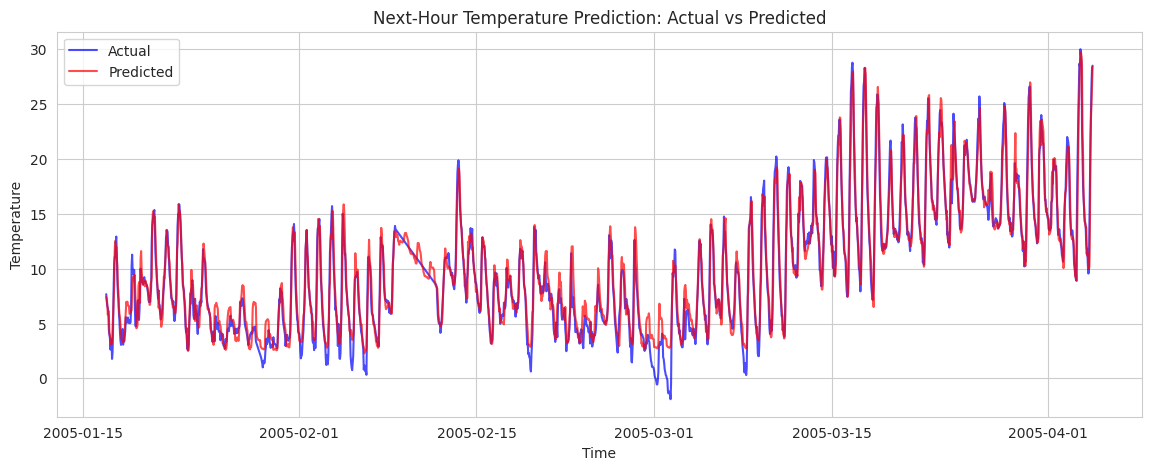

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming y_test and y_pred from your pipeline
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}, index=y_test.index)

# 1) Line plot: Actual vs Predicted (time series)
plt.figure(figsize=(14,5))
plt.plot(results_df['Actual'], label='Actual', color='blue', alpha=0.7)
plt.plot(results_df['Predicted'], label='Predicted', color='red', alpha=0.7)
plt.title("Next-Hour Temperature Prediction: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()




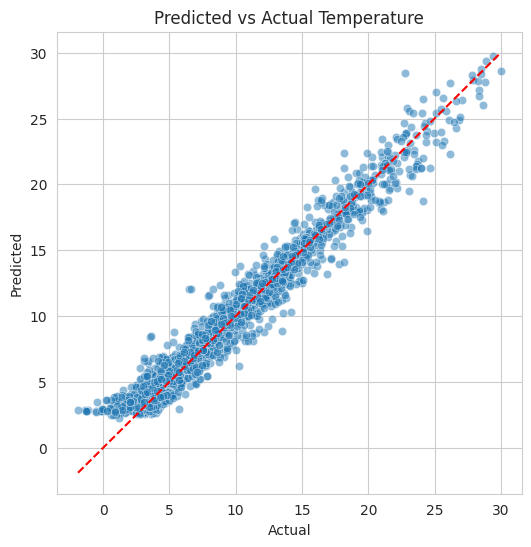

In [23]:
# 2) Scatter plot: Predicted vs Actual
plt.figure(figsize=(6,6))
sns.scatterplot(x='Actual', y='Predicted', data=results_df, alpha=0.5)
plt.plot([results_df['Actual'].min(), results_df['Actual'].max()],
         [results_df['Actual'].min(), results_df['Actual'].max()],
         color='red', linestyle='--')
plt.title("Predicted vs Actual Temperature")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.show()



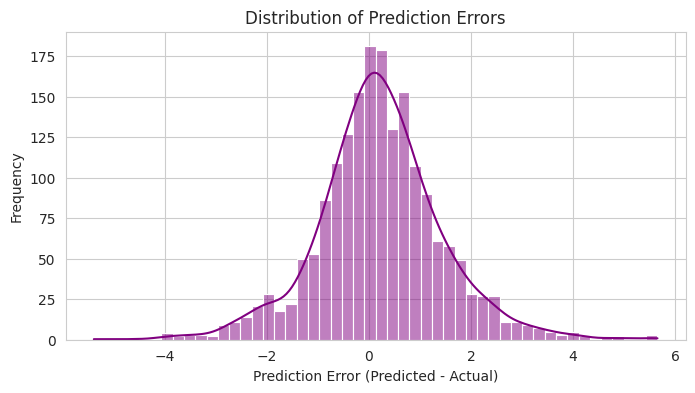

In [26]:
# 3) Error distribution
results_df['Error'] = results_df['Predicted'] - results_df['Actual']
plt.figure(figsize=(8,4))
sns.histplot(results_df['Error'], bins=50, kde=True, color='purple')
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


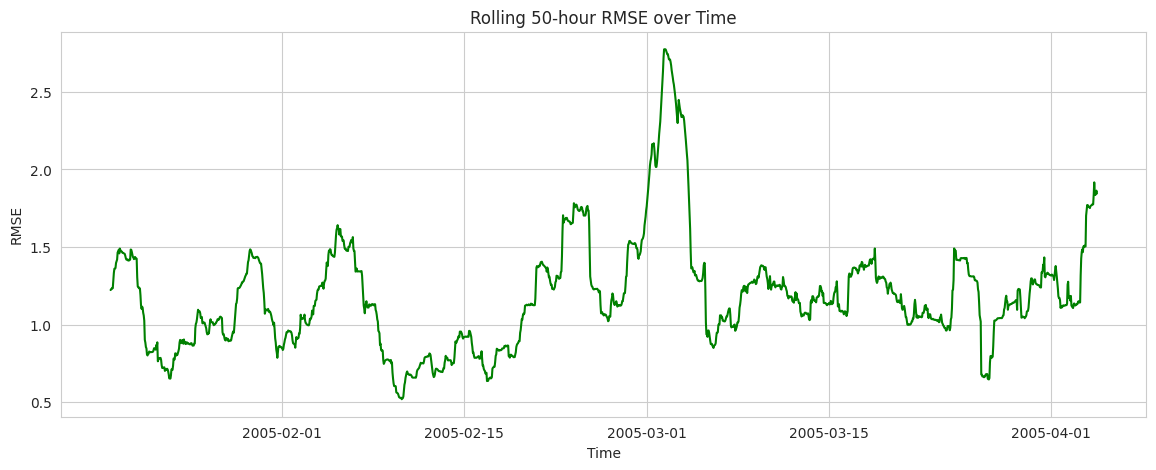

In [25]:

# 4) Optional: Rolling RMSE over time (to see performance drift)
window = 50  # rolling window
results_df['Rolling_RMSE'] = (results_df['Error']**2).rolling(window).mean().apply(np.sqrt)
plt.figure(figsize=(14,5))
plt.plot(results_df['Rolling_RMSE'], color='green')
plt.title(f"Rolling {window}-hour RMSE over Time")
plt.xlabel("Time")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()